###**Deep Learning Assignment-4 : CNN Architecture Design & Parameter Calculation**

**Name:** Yesha Pandya

**Enrolment Number:** 23BT04175

**Div:** 1 **Batch:** C

**Objective:**

On any dataset of your choice:
1. Design a CNN classification Model to classify the images with following features:
    * Layer 1 - 32 Filters 3 X 3
    * Same Padding
    * Stride - 2
    * Max Pooling - 2
    * Layer 2 - 24 Filters 5 X 5
    * No padding
    * Stride -3
    * Max Pooling 2
    * Fully Connected layer
    * Dense layer
    * Output layer
2. Write the count of parameters after each step
3. Plot the accuracy for train and test data

#### **Chosen dataset: CIFAR-10**
The CIFAR-10 dataset consists of 60,000 $32 \times 32$ pixel color images categorized into 10 distinct classes. It is utilized in this experiment out of mathematical necessity due to the highly rigid architectural constraints outlined in the assignment.

**Why use this?**
* **Aggressive Downsampling:** The assigned architecture requires a severe and unconventional reduction in spatial dimensions (Stride 2 $\rightarrow$ Max Pooling $\rightarrow$ Stride 3 $\rightarrow$ Max Pooling).
* **Dimensional Viability:** Standard introductory datasets, such as the $28 \times 28$ MNIST dataset, cannot survive this degree of downsampling. Their feature maps would collapse to a $0 \times 0$ dimension before reaching the dense layers, resulting in a network failure.
* **Mathematical Alignment:** Starting with CIFAR-10's $32 \times 32$ spatial dimensions ensures that the matrices gracefully reduce to a valid $1 \times 1 \times 24$ shape right before the flattening step, perfectly satisfying the strict layer parameters.

In [2]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalize pixel values to be between 0 and 1
# Normalization improves numerical stability and helps the optimizer converge faster
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

Loading CIFAR-10 dataset...
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


#### **Data Visualization**
Before passing the data into the Convolutional Neural Network; it is best practice to verify the dataset's integrity. We'll visualize one sample image from each of the 10 classes present in the CIFAR-10 dataset.

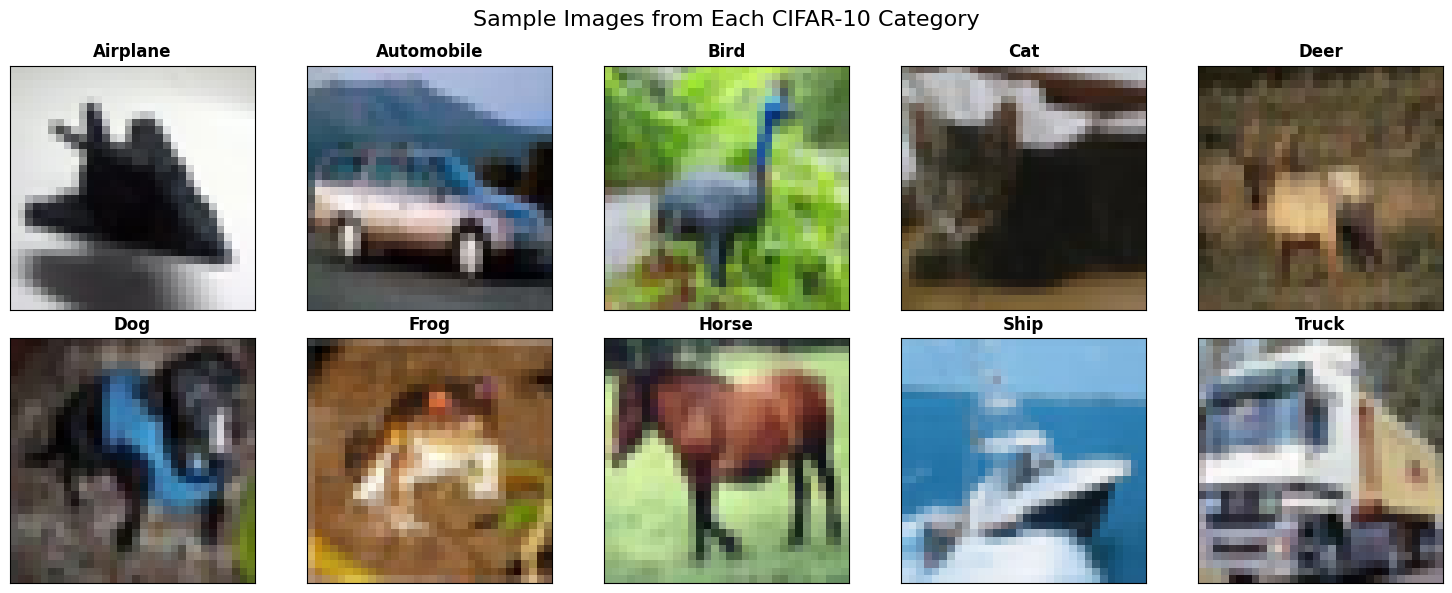

In [3]:
# define the 10 class names for CIFAR-10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# create a figure to display the images
plt.figure(figsize=(15, 6))

# iterate through each of the 10 classes to find and plot one example
for i in range(10):
    # find the index of the first image belonging to class 'i'
    index = np.where(y_train == i)[0][0]

    # create a subplot for the image
    plt.subplot(2, 5, i + 1)
    plt.xticks([]) # remove x-axis ticks
    plt.yticks([]) # remove y-axis ticks
    plt.grid(False)

    # display the image and set the label as the title
    plt.imshow(x_train[index])
    plt.title(class_names[i], fontsize=12, fontweight='bold')

plt.suptitle("Sample Images from Each CIFAR-10 Category", fontsize=16)
plt.tight_layout()
plt.show()

#### **CNN Architecture Design & Parameter Calculation**
The model is designed exactly to the assignment specifications.

Below is the manual mathematical calculation for the learnable parameters at each step.

Formulas used:
* Conv2D Parameters: $(\text{Filter Width} \times \text{Filter Height} \times \text{Input Channels} + 1 \text{ bias}) \times \text{Number of Filters}$
* Dense Layer Parameters: $(\text{Input Size} + 1 \text{ bias}) \times \text{Number of Neurons}$
* Valid Padding Spatial Output: $\lfloor(\text{Input Size} - \text{Filter Size}) / \text{Stride}\rfloor + 1$

Mathematical Breakdown
* Input Shape: $32 \times 32 \times 3$
* Layer 1 (Conv2D): 32 Filters, $3 \times 3$, Same Padding, Stride 2
  * Output Shape: $16 \times 16 \times 32$
  * Parameters: $(3 \times 3 \times 3 + 1) \times 32 = 896$
* Max Pooling 1: Pool Size $2 \times 2$
  * Output Shape: $8 \times 8 \times 32$
  * Parameters: $0$ (Pooling involves no learnable weights)
* Layer 2 (Conv2D): 24 Filters, $5 \times 5$, No Padding (Valid), Stride 3Output Spatial Dimension: $\lfloor(8 - 5) / 3\rfloor + 1 = \lfloor1\rfloor + 1 = 2$
  * Output Shape: $2 \times 2 \times 24$
  * Parameters: $(5 \times 5 \times 32 + 1) \times 24 = (800 + 1) \times 24 = 19,224$
* Max Pooling 2: Pool Size $2 \times 2$
  * Output Shape: $1 \times 1 \times 24$
  * Parameters: $0$
* Fully Connected Layer (Flatten):
  * Output Shape: $24$ (Flattens the 3D tensor into a 1D vector)
  * Parameters: $0$
* Dense Layer: 64 Neurons
  * Output Shape: $64$
  * Parameters: $(24 \text{ inputs} + 1 \text{ bias}) \times 64 = 25 \times 64 = 1,600$
* Output Layer: 10 Neurons (for 10 classes)
  * Output Shape: $10$
  * Parameters: $(64 \text{ inputs} + 1 \text{ bias}) \times 10 = 65 \times 10 = 650

* Total Network Parameters: $896 + 19,224 + 1,600 + 650 = 22,370$

In [5]:
# Initialize the Sequential model framework
model = models.Sequential()

# Layer 1 - 32 Filters 3x3, Same Padding, Stride 2
model.add(layers.Conv2D(32, (3, 3), padding='same', strides=(2, 2),
                        activation='relu', input_shape=(32, 32, 3), name='Conv2D_Layer_1'))

# Max Pooling - 2
model.add(layers.MaxPooling2D((2, 2), name='MaxPool_1'))

# Layer 2 - 24 Filters 5x5, No padding ('valid'), Stride 3
model.add(layers.Conv2D(24, (5, 5), padding='valid', strides=(3, 3),
                        activation='relu', name='Conv2D_Layer_2'))

# Max Pooling - 2
model.add(layers.MaxPooling2D((2, 2), name='MaxPool_2'))

# Fully Connected layer (Flattening)
model.add(layers.Flatten(name='Flatten_Layer'))

# Dense layer
model.add(layers.Dense(64, activation='relu', name='Dense_Hidden_Layer'))

# Output layer (10 neurons with Softmax for multi-class classification)
model.add(layers.Dense(10, activation='softmax', name='Output_Layer'))

# Print the model summary to computationally verify the manual math above
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2D_Layer_1 (Conv2D)         │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_Layer_2 (Conv2D)         │ (None, 2, 2, 24)       │        19,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten_Layer (Flatten)         │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden_Layer (Dense)      │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,370 (87.38 KB)

 Trainable params: 22,370 (87.38 KB)

 Non-trainable params: 0 (0.00 B)

#### **Model Compilation and Training**
We'll use the Adam optimizer (an efficient extension of stochastic gradient descent) and Sparse Categorical Crossentropy as our loss function. This is the standard choice when our ground truth labels are integers rather than one-hot encoded vectors.

We'll train the model for 20 epochs and store the validation results to plot the learning curves.

In [6]:
# Compile the CNN model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model, utilizing the test set for validation data at each epoch
print("Initiating Model Training...")
history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_data=(x_test, y_test))
print("Training Completed Successfully.")

Initiating Model Training...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.3245 - loss: 1.8161 - val_accuracy: 0.4010 - val_loss: 1.6216
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4370 - loss: 1.5313 - val_accuracy: 0.4349 - val_loss: 1.5130
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4909 - loss: 1.4047 - val_accuracy: 0.5068 - val_loss: 1.3617
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5197 - loss: 1.3317 - val_accuracy: 0.5246 - val_loss: 1.3005
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5411 - loss: 1.2774 - val_accuracy: 0.5314 - val_loss: 1.2801
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5556 - loss: 1.2392 - val_accuracy: 0.5168 - val_loss: 1.3221
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5694 - loss: 1.2028 - val_accuracy: 0.5558 - val_loss: 1.2460
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accur

#### **Training Evaluation & Visualization**
Finally, we'll plot the accuracy for both the training and test data. We will also plot the loss to provide a comprehensive view of the model's convergence and to check for potential overfitting.

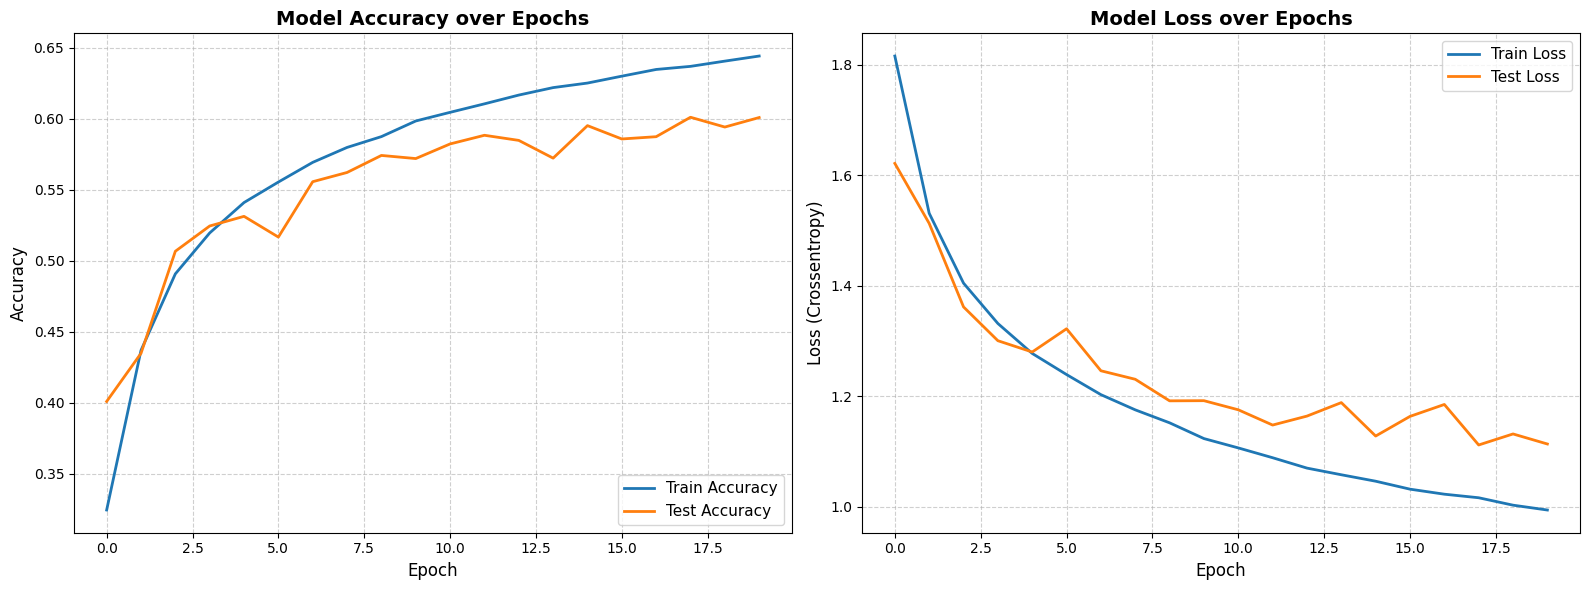

In [7]:
# Create a figure with two subplots: one for Accuracy and one for Loss
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Model Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Test Accuracy', color='#ff7f0e', linewidth=2)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Model Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Test Loss', color='#ff7f0e', linewidth=2)
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (Crossentropy)', fontsize=12)
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Render the plots
plt.tight_layout()
plt.show()